In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:

from google.colab import files

uploaded = files.upload()


Saving archive.zip to archive.zip


In [3]:

import pandas as pd

file_name = next(iter(uploaded))
df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

display(df.head())


Dataset loaded successfully!
Rows and columns: (1000, 9)

Column names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:

# 1. Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

# 2. Check duplicate records
print("\nDuplicate rows:", df.duplicated().sum())

# 3. Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# 4. Remove duplicate rows
df = df.drop_duplicates().copy()

# 5. Check data types
print("\nData types:")
print(df.dtypes)

# 6. Display dataset summary
print("\nDataset shape after cleaning:", df.shape)
display(df.head())



Missing values in each column:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate rows: 0

Data types:
Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

Dataset shape after cleaning: (1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [5]:

# Select numerical columns
numeric_cols = [
    "Age", "Quantity", "Price per Unit", "Total Amount"
]

# Calculate mean, median, mode, and standard deviation
statistics = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Mode": df[numeric_cols].mode().iloc[0],
    "Standard Deviation": df[numeric_cols].std()
})

display(statistics.round(2))


,Mean,Median,Mode,Standard Deviation
Age,41.39,42.0,43.0,13.68
Quantity,2.51,3.0,4.0,1.13
Price per Unit,179.89,50.0,50.0,189.68
Total Amount,456.00,135.0,50.0,560.00


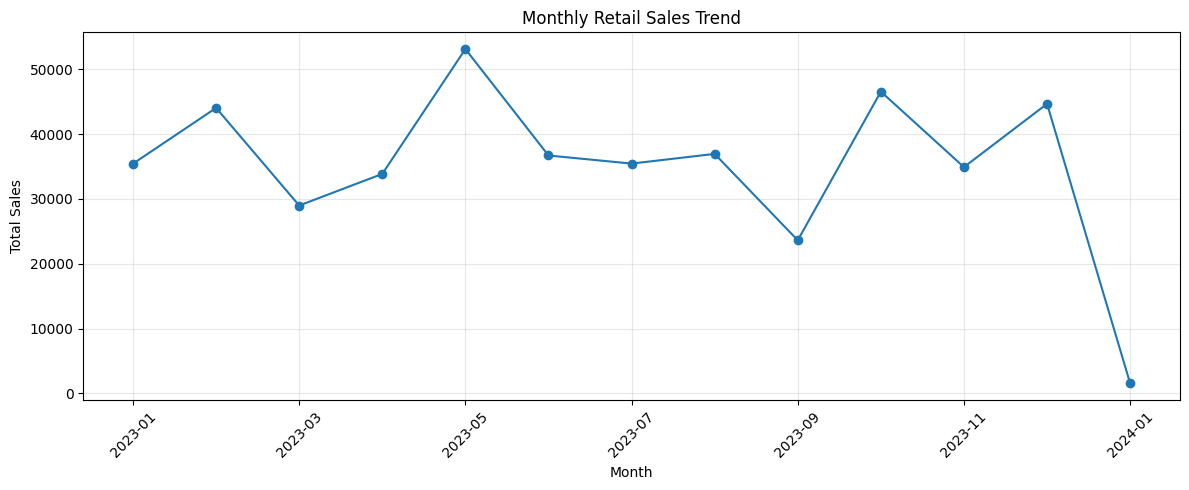

,Total Amount
Month,
2023-01,35450
2023-02,44060
2023-03,28990
2023-04,33870
2023-05,53150
2023-06,36715
2023-07,35465
2023-08,36960
2023-09,23620


In [6]:

# Extract month and calculate monthly sales
df["Month"] = df["Date"].dt.to_period("M").astype(str)

monthly_sales = (
    df.groupby("Month")["Total Amount"]
    .sum()
    .sort_index()
)

# Plot monthly sales
plt.figure(figsize=(12, 5))
monthly_sales.plot(marker="o")
plt.title("Monthly Retail Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(monthly_sales)


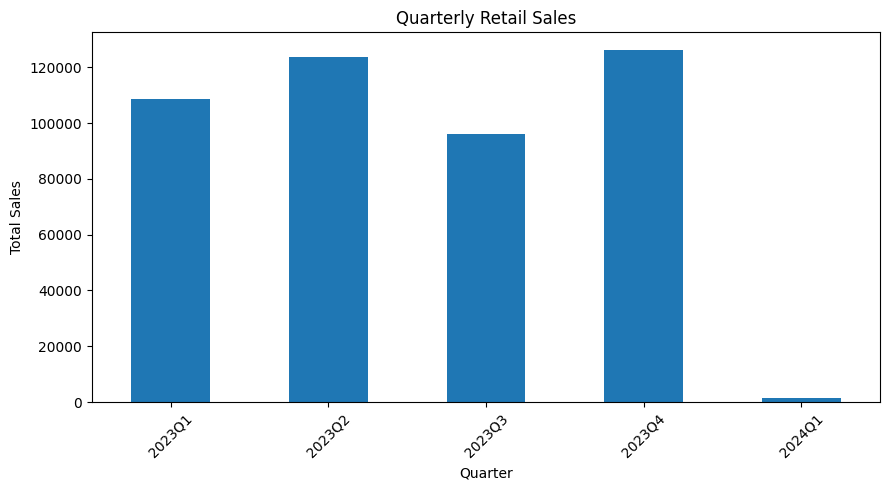

,Total Amount
Quarter,
2023Q1,108500
2023Q2,123735
2023Q3,96045
2023Q4,126190
2024Q1,1530


In [7]:

# Extract quarter from the transaction date
df["Quarter"] = df["Date"].dt.to_period("Q").astype(str)

quarterly_sales = df.groupby("Quarter")["Total Amount"].sum()

plt.figure(figsize=(9, 5))
quarterly_sales.plot(kind="bar")
plt.title("Quarterly Retail Sales")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(quarterly_sales)


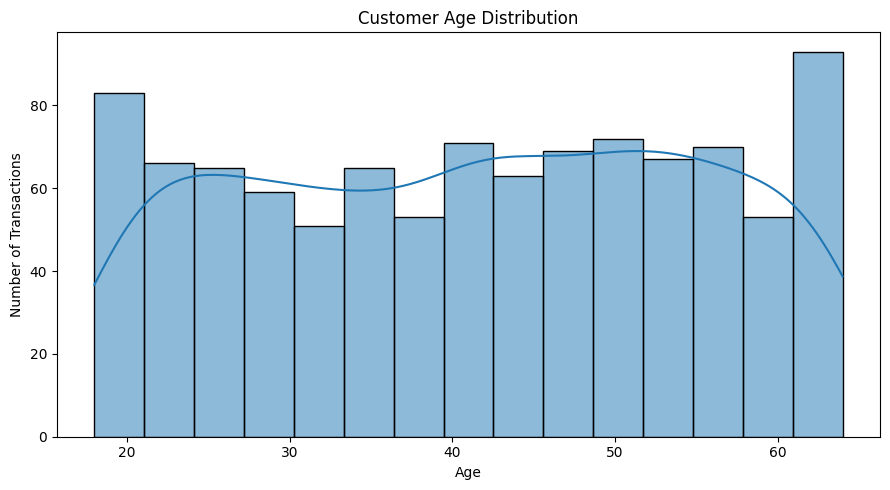

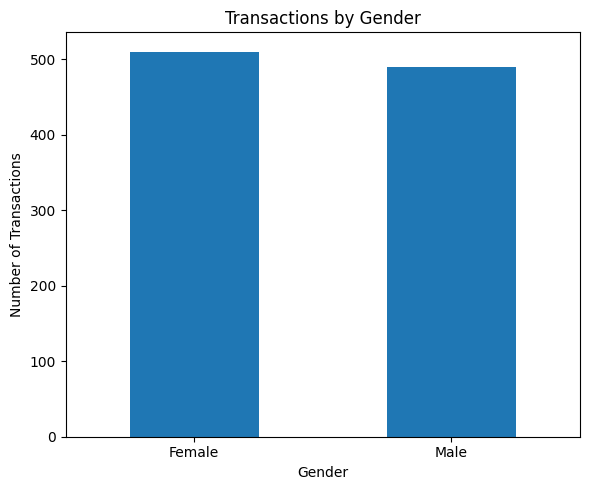

,count
Gender,
Female,510
Male,490


In [8]:

# Customer age distribution
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="Age", bins=15, kde=True)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

# Gender breakdown
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(6, 5))
gender_counts.plot(kind="bar")
plt.title("Transactions by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(gender_counts)


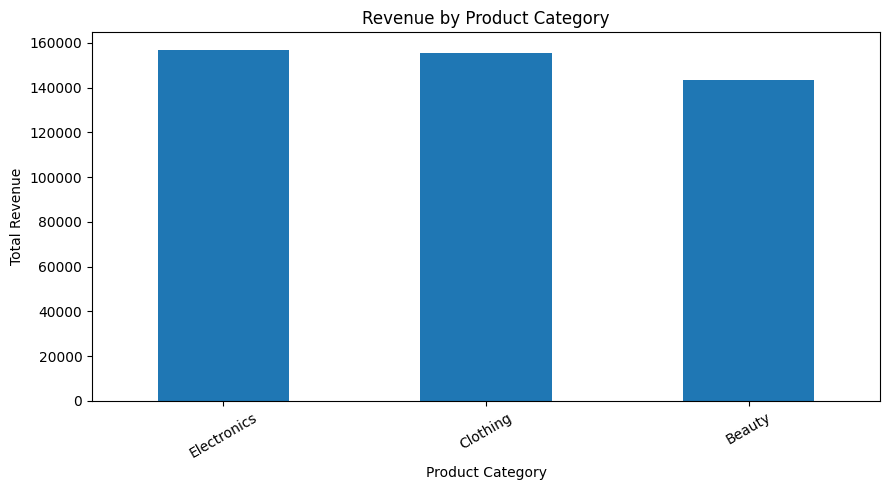

,Total Amount
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515


,Transaction ID,Product Category,Quantity,Total Amount
14,15,Electronics,4,2000
64,65,Electronics,4,2000
71,72,Electronics,4,2000
73,74,Beauty,4,2000
88,89,Electronics,4,2000
92,93,Beauty,4,2000
108,109,Electronics,4,2000
117,118,Electronics,4,2000
123,124,Clothing,4,2000
138,139,Beauty,4,2000


In [9]:

# Revenue by product category
category_revenue = (
    df.groupby("Product Category")["Total Amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
category_revenue.plot(kind="bar")
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

display(category_revenue)

# Top 10 transactions by total amount
top10 = df.nlargest(10, "Total Amount")[
    ["Transaction ID", "Product Category", "Quantity", "Total Amount"]
]

display(top10)


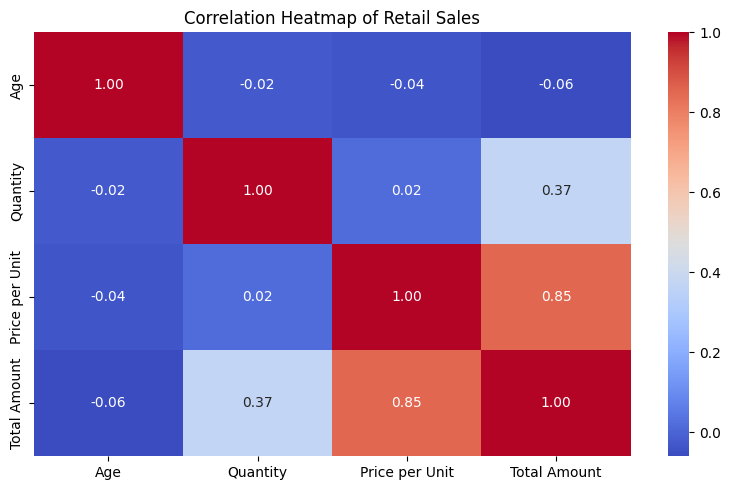

In [10]:

numeric_data = df[
    ["Age", "Quantity", "Price per Unit", "Total Amount"]
]

plt.figure(figsize=(8, 5))
sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap of Retail Sales")
plt.tight_layout()
plt.show()


In [11]:

print("Total revenue:", df["Total Amount"].sum())
print("Total transactions:", len(df))
print("Average transaction amount:", round(df["Total Amount"].mean(), 2))
print("Best revenue category:", category_revenue.idxmax())
print("Highest-sales month:", monthly_sales.idxmax())
print("Highest-sales quarter:", quarterly_sales.idxmax())
print("Most frequent customer gender:", gender_counts.idxmax())


Total revenue: 456000
Total transactions: 1000
Average transaction amount: 456.0
Best revenue category: Electronics
Highest-sales month: 2023-05
Highest-sales quarter: 2023Q4
Most frequent customer gender: Female


## Key Findings

1. The retail dataset contains 1,000 transactions and total revenue of ₹4,56,000.
2. The average transaction amount is ₹456.
3. Electronics is the highest-revenue product category.
4. May 2023 recorded the highest monthly sales.
5. The fourth quarter of 2023 recorded the highest quarterly sales.
6. Female customers account for the most frequent customer gender in the dataset.
7. Price per unit has a strong positive correlation with total amount (0.85), while age has a very weak negative correlation with total amount (-0.06).

## Business Recommendations

1. **Inventory planning:** Use sales trends to plan inventory and staffing around high-demand periods.
2. **Category marketing:** Develop targeted promotions based on product category performance.
3. **Customer marketing:** Analyze purchasing patterns across customer demographics to design relevant campaigns.
4. **Pricing strategy:** Review product prices and quantities sold to identify opportunities to increase transaction value.

## Conclusion

Exploratory Data Analysis identified retail sales trends, customer demographics, product category performance, and relationships between numerical variables. These findings can support data-driven inventory planning, marketing, and pricing decisions.

In [14]:

readme_content = """
# Retail Sales Data Analysis (EDA)

## Internship
Oasis Infobyte - Data Analytics Internship

## Project Overview
This project performs Exploratory Data Analysis (EDA) on a retail
sales dataset containing 1,000 transactions. The goal is to understand
sales trends, customer demographics, product category performance,
and relationships between numerical variables.

## Objectives
- Inspect and clean the dataset.
- Calculate descriptive statistics.
- Analyze monthly and quarterly sales.
- Explore customer age and gender distributions.
- Identify high-revenue product categories.
- Visualize correlations between numerical variables.
- Provide actionable business recommendations.

## Tools and Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

## Analysis Performed
1. Dataset inspection and missing-value checks.
2. Duplicate record checks and date conversion.
3. Mean, median, mode, and standard deviation calculations.
4. Monthly and quarterly sales trend visualizations.
5. Customer demographics analysis.
6. Revenue analysis by product category.
7. Top 10 transaction analysis by total amount.
8. Correlation heatmap.

## Key Findings
- Total transactions: 1,000
- Total revenue: Rs. 456,000
- Average transaction amount: Rs. 456
- Highest-revenue category: Electronics
- Highest-sales month: May 2023
- Highest-sales quarter: 2023 Q4
- Most frequent customer gender: Female
- Correlation between price per unit and total amount: 0.85
- Correlation between age and total amount: -0.06

## Business Recommendations
1. Use sales trends to plan inventory and staffing.
2. Develop targeted promotions based on category performance.
3. Analyze customer purchasing patterns to improve marketing.
4. Review pricing and quantities sold to identify opportunities
   to increase transaction value.

## Conclusion
The analysis identifies retail sales patterns, customer demographics,
category performance, and relationships between numerical variables.
These findings can support data-driven business decisions.

## Project File
Retail_Sales_EDA.ipynb

## Author
Layeeqa Anjum K
"""

with open("README.md", "w", encoding="utf-8") as file:
    file.write(readme_content)

print("README.md created successfully!")


README.md created successfully!


In [15]:

from google.colab import files
files.download("README.md")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>